## Deutsch-Jozsa
Decide con **una sola consulta** si una función es *constante* o *balanceada*.
Si todos los qubits de entrada miden `000` → constante; cualquier otra cosa → balanceada.

In [2]:
import numpy as np
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Operator
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

sim = AerSimulator()

def correr(qc, shots=1024):
    """Ejecuta un circuito en el simulador y devuelve los conteos."""
    return sim.run(transpile(qc, sim), shots=shots).result().get_counts()

constante_0 -> {'000': 1024}
constante_1 -> {'000': 1024}
balanceada -> {'111': 1024}


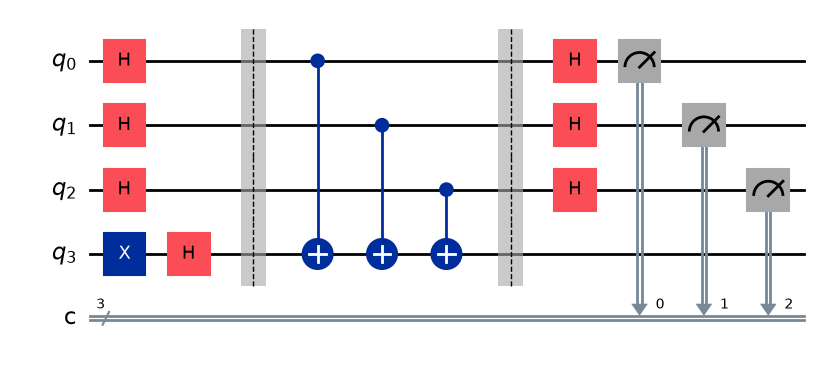

In [3]:
def deutsch_jozsa(n, tipo):
    qc = QuantumCircuit(n + 1, n)
    qc.x(n); qc.h(range(n + 1))          # ancilla en |->, entradas en superposición
    qc.barrier()
    # --- oráculo ---
    if tipo == "constante_1":
        qc.x(n)                           # f(x)=1 siempre
    elif tipo == "balanceada":
        for i in range(n):
            qc.cx(i, n)                   # f(x)=paridad de x
    # tipo "constante_0": no hace nada
    qc.barrier()
    qc.h(range(n))
    qc.measure(range(n), range(n))
    return qc

for tipo in ["constante_0", "constante_1", "balanceada"]:
    print(tipo, "->", correr(deutsch_jozsa(3, tipo)))

deutsch_jozsa(3, "balanceada").draw("mpl")